In [1]:
import pandas as pd
import numpy as np


In [2]:
# Generate synthetic dataset
np.random.seed(42)
data = {
    'price': np.random.uniform(0.8, 1.5, 300),
    'promo_discount': np.random.choice([0, 0.1, 0.2, 0.3], 300),
    'holiday': np.random.binomial(1, 0.15, 300),
    'temperature': np.random.randint(25, 38, 300),
    'social_media_mentions': np.random.poisson(150, 300),
    'competitor_price': np.random.uniform(0.7, 1.6, 300),
    'historical_demand': np.random.normal(10000, 2500, 300)
}

# Calculate target variable: demand (units)
data['demand'] = (50000 
                 - 12000*data['price'] 
                 + 8000*data['promo_discount'] 
                 + 15000*data['holiday'] 
                 - 300*data['temperature'] 
                 + 15*data['social_media_mentions'] 
                 + 2000*data['competitor_price'] 
                 + 0.7*data['historical_demand']
                 + np.random.normal(0, 2000, 300))

df = pd.DataFrame(data)
df.head()


,price,promo_discount,holiday,temperature,social_media_mentions,competitor_price,historical_demand,demand
0,1.062178,0.0,0,27,147,0.944033,9734.845227,39933.179446
1,1.465500,0.3,0,30,169,1.233531,13054.992802,38774.005406
2,1.312396,0.3,0,30,157,1.312119,7321.864626,40716.929714
3,1.219061,0.1,1,27,151,0.907746,10014.630842,52743.302287
4,0.909213,0.2,0,31,150,1.111173,13909.339040,46286.015955


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split features/target
X = df.drop('demand', axis=1)
y = df['demand']

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)


In [6]:
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Baseline RMSE: {rmse:.2f} units")
print(f"Baseline R²: {r2:.4f}")


Baseline RMSE: 2543.37 units
Baseline R²: 0.8845


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")


Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


<Axes: title={'center': 'Demand Drivers'}>

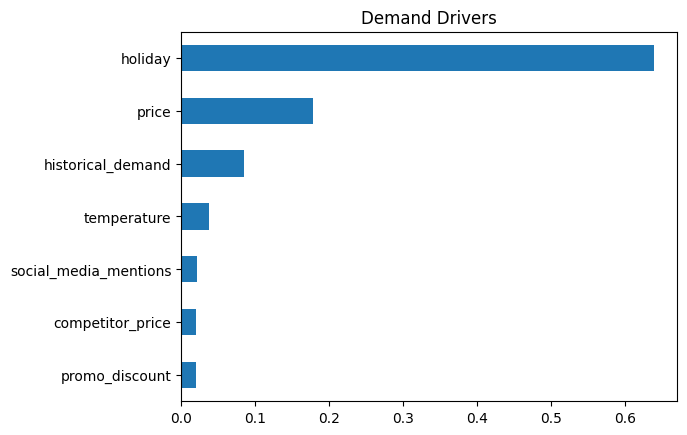

In [9]:
importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', title='Demand Drivers')
